In [1]:
"""
ResNet50 image classifier with CAM support.

Expected directory layout:
repo/
└── data/
    ├── train/
    │   ├── class_0/
    │   └── ...
    ├── valid/
    │   ├── class_0/
    │   └── ...
    └── test/
        ├── class_0/
        └── ...

Features:
- Pretrained ResNet50 backbone
- CAM-friendly head: feature map -> GAP -> flatten -> classifier
- Train on train split, validate on valid split, test on test split
- Adam optimizer, 50 epochs
- Save best model checkpoint
- Plot train/val accuracy and loss curves
- Plot confusion matrix
- Load model and test loader
- Compute and plot Class Activation Maps (CAM)

Notes:
- CAM works only when the classifier is connected directly to the last convolutional feature map followed by global average pooling.
- This implementation uses the last feature map from torchvision ResNet50 before pooling.
"""

'ResNet50 image classifier with CAM support.\n\nExpected directory layout:\nrepo/\n└── data/\n    ├── train/\n    │   ├── class_0/\n    │   └── ...\n    ├── valid/\n    │   ├── class_0/\n    │   └── ...\n    └── test/\n        ├── class_0/\n        └── ...\n\nFeatures:\n- Pretrained ResNet50 backbone\n- CAM-friendly head: feature map -> GAP -> flatten -> classifier\n- Train on train split, validate on valid split, test on test split\n- Adam optimizer, 50 epochs\n- Save best model checkpoint\n- Plot train/val accuracy and loss curves\n- Plot confusion matrix\n- Load model and test loader\n- Compute and plot Class Activation Maps (CAM)\n\nNotes:\n- CAM works only when the classifier is connected directly to the last convolutional feature map followed by global average pooling.\n- This implementation uses the last feature map from torchvision ResNet50 before pooling.\n'

In [2]:
from __future__ import annotations

import os
import json
import math
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms


In [5]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------


@dataclass
class Config:
    data_dir: str = "/mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/learn-by-rebuilding/dlcv/cam-what-cnn-is-looking-at/data/"
    train_dir: str = "train"
    valid_dir: str = "valid"
    test_dir: str = "test"
    image_size: int = 224
    batch_size: int = 32
    num_workers: int = 4
    num_epochs: int = 5
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    num_classes: int = 100
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    model_save_path: str = "resnet50_cam_best.pt"
    history_save_path: str = "training_history.json"
    plot_save_dir: str = "plots"
    seed: int = 42
    freeze_backbone: bool = False
    use_amp: bool = True


In [ ]:
# -----------------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------------

def set_seed(seed: int = 42) -> None:
    import random

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


In [ ]:
# -----------------------------------------------------------------------------
# Data transforms and loaders
# -----------------------------------------------------------------------------

def get_data_transforms(image_size: int = 224):
    # ImageNet normalization for pretrained ResNet50
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    train_tfms = transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    eval_tfms = transforms.Compose([
        transforms.Resize(int(image_size * 1.14)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    # For CAM visualization: tensor transform without normalization will be helpful
    cam_vis_tfms = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ])

    return train_tfms, eval_tfms, cam_vis_tfms


def build_datasets(data_dir: str, image_size: int = 224):
    train_tfms, eval_tfms, cam_vis_tfms = get_data_transforms(image_size)

    train_path = Path(data_dir) / "train"
    valid_path = Path(data_dir) / "valid"
    test_path = Path(data_dir) / "test"

    train_dataset = datasets.ImageFolder(train_path, transform=train_tfms)
    valid_dataset = datasets.ImageFolder(valid_path, transform=eval_tfms)
    test_dataset = datasets.ImageFolder(test_path, transform=eval_tfms)

    # For CAM / raw image fetching, keep a parallel dataset with non-normalized tensor transforms
    cam_dataset = datasets.ImageFolder(test_path, transform=cam_vis_tfms)

    return train_dataset, valid_dataset, test_dataset, cam_dataset


def build_dataloaders(
    data_dir: str,
    batch_size: int = 32,
    num_workers: int = 4,
    image_size: int = 224,
):
    train_dataset, valid_dataset, test_dataset, cam_dataset = build_datasets(data_dir, image_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )
    cam_loader = DataLoader(
        cam_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    class_names = train_dataset.classes
    class_to_idx = train_dataset.class_to_idx

    return train_loader, valid_loader, test_loader, cam_loader, class_names, class_to_idx


In [ ]:
# -----------------------------------------------------------------------------
# Model: ResNet50 with CAM-friendly classifier
# -----------------------------------------------------------------------------

class ResNet50CAM(nn.Module):
    def __init__(self, num_classes: int = 100, freeze_backbone: bool = False):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        backbone = models.resnet50(weights=weights)

        # Keep everything except avgpool and fc as the convolutional feature extractor.
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-2])
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(2048, num_classes)

        if freeze_backbone:
            for param in self.feature_extractor.parameters():
                param.requires_grad = False

        self._init_classifier()

    def _init_classifier(self):
        nn.init.normal_(self.classifier.weight, 0, 0.01)
        if self.classifier.bias is not None:
            nn.init.zeros_(self.classifier.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.feature_extractor(x)   # [B, 2048, H, W]
        pooled = self.gap(features)            # [B, 2048, 1, 1]
        flattened = torch.flatten(pooled, 1)   # [B, 2048]
        logits = self.classifier(flattened)     # [B, num_classes]
        return logits

    def extract_feature_maps(self, x: torch.Tensor) -> torch.Tensor:
        return self.feature_extractor(x)


In [ ]:
# -----------------------------------------------------------------------------
# Training / evaluation helpers
# -----------------------------------------------------------------------------


def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct / total if total > 0 else 0.0


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: str):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    all_preds = []
    all_targets = []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, targets)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == targets).sum().item()
        running_total += targets.size(0)

        all_preds.append(preds.detach().cpu())
        all_targets.append(targets.detach().cpu())

    avg_loss = running_loss / running_total
    avg_acc = running_correct / running_total
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    return avg_loss, avg_acc, all_targets, all_preds


def train_one_epoch(model: nn.Module, loader: DataLoader, criterion: nn.Module, optimizer: optim.Optimizer, device: str, scaler: Optional[torch.cuda.amp.GradScaler] = None):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == targets).sum().item()
        running_total += targets.size(0)

    avg_loss = running_loss / running_total
    avg_acc = running_correct / running_total
    return avg_loss, avg_acc


def save_checkpoint(path: str, model: nn.Module, optimizer: optim.Optimizer, epoch: int, class_to_idx: Dict[str, int], config: Config, best_val_acc: float, history: Dict[str, List[float]]):
    ckpt = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "class_to_idx": class_to_idx,
        "config": asdict(config),
        "best_val_acc": best_val_acc,
        "history": history,
    }
    torch.save(ckpt, path)


def load_checkpoint(path: str, device: str = "cpu"):
    ckpt = torch.load(path, map_location=device)
    config_dict = ckpt.get("config", {})
    num_classes = config_dict.get("num_classes", 100)
    freeze_backbone = config_dict.get("freeze_backbone", False)

    model = ResNet50CAM(num_classes=num_classes, freeze_backbone=freeze_backbone)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    model.eval()
    return model, ckpt


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    class_to_idx: Dict[str, int],
    config: Config,
):
    os.makedirs(config.plot_save_dir, exist_ok=True)
    device = config.device
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scaler = torch.cuda.amp.GradScaler() if (config.use_amp and device.startswith("cuda")) else None

    history = {
        "train_loss": [],
        "train_acc": [],
        "valid_loss": [],
        "valid_acc": [],
    }

    best_val_acc = -math.inf

    for epoch in range(1, config.num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
        valid_loss, valid_acc, _, _ = evaluate(model, valid_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        print(
            f"Epoch [{epoch:02d}/{config.num_epochs}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {valid_loss:.4f} | Val Acc: {valid_acc:.4f}"
        )

        if valid_acc > best_val_acc:
            best_val_acc = valid_acc
            save_checkpoint(config.model_save_path, model, optimizer, epoch, class_to_idx, config, best_val_acc, history)
            print(f"  -> Saved best checkpoint to {config.model_save_path}")

    with open(config.history_save_path, "w") as f:
        json.dump(history, f, indent=2)

    return history


In [ ]:
# -----------------------------------------------------------------------------
# Plotting helpers
# -----------------------------------------------------------------------------

def plot_training_curves(history: Dict[str, List[float]], save_path: Optional[str] = None):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["valid_loss"], label="Validation Loss")
    axes[0].set_title("Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], label="Train Accuracy")
    axes[1].plot(epochs, history["valid_acc"], label="Validation Accuracy")
    axes[1].set_title("Accuracy Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names: List[str], save_path: Optional[str] = None, normalize: bool = False):
    if normalize:
        cm = confusion_matrix(y_true, y_pred, normalize="true")
    else:
        cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(18, 16))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=True, values_format=".2f" if normalize else "d")
    ax.set_title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


In [ ]:
# -----------------------------------------------------------------------------
# Test helper
# -----------------------------------------------------------------------------


def test_model(model: nn.Module, test_loader: DataLoader, class_names: List[str], device: str):
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    return test_loss, test_acc, y_true, y_pred


In [ ]:
# -----------------------------------------------------------------------------
# CAM utilities
# -----------------------------------------------------------------------------

def denormalize_image(img_tensor: torch.Tensor) -> np.ndarray:
    """Convert a tensor image [C,H,W] normalized with ImageNet mean/std back to RGB uint8."""
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=img_tensor.dtype, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=img_tensor.dtype, device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    img = img.permute(1, 2, 0).detach().cpu().numpy()
    img = (img * 255).astype(np.uint8)
    return img


@torch.no_grad()
def get_class_activation_map(model: nn.Module, img: torch.Tensor, class_idx: Optional[int] = None) -> np.ndarray:
    """Compute CAM for a single image tensor.

    Args:
        model: trained ResNet50CAM model.
        img: tensor of shape [1, 3, H, W]. It should be normalized the same way as the model input.
        class_idx: class index for which CAM is computed. If None, use predicted class.

    Returns:
        cam: numpy array of shape [H_feat, W_feat] normalized to [0, 1].
    """
    model.eval()

    if img.dim() != 4 or img.size(0) != 1:
        raise ValueError("img must have shape [1, 3, H, W]")

    device = next(model.parameters()).device
    img = img.to(device)

    feature_maps = model.extract_feature_maps(img)  # [1, 2048, h, w]
    logits = model(img)
    pred_idx = int(torch.argmax(logits, dim=1).item())

    if class_idx is None:
        class_idx = pred_idx

    weights = model.classifier.weight[class_idx]  # [2048]
    cam = torch.zeros(feature_maps.shape[2:], device=device)

    for i, w in enumerate(weights):
        cam += w * feature_maps[0, i, :, :]

    cam = torch.relu(cam)
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam.detach().cpu().numpy()


def plot_class_activation_map(CAM: np.ndarray, img: torch.Tensor, label: str, data_path: str, ax=None):
    """Overlay CAM on the original image.

    Args:
        CAM: 2D numpy array from get_class_activation_map.
        img: image tensor. If passed from dataset with eval transform, should be [3,H,W] or [1,3,H,W].
        label: class label text.
        data_path: kept for compatibility with your requested signature; not strictly required.
        ax: matplotlib axis.
    """
    if img.dim() == 4:
        img = img.squeeze(0)

    # Try to visualize by de-normalizing assuming ImageNet normalization if data is normalized.
    # If the tensor is already unnormalized [0,1], this still produces a valid image.
    img_np = denormalize_image(img) if img.max() <= 3 else img.permute(1, 2, 0).detach().cpu().numpy()
    img_np = np.clip(img_np, 0, 255).astype(np.uint8)

    cam_resized = Image.fromarray((CAM * 255).astype(np.uint8)).resize((img_np.shape[1], img_np.shape[0]), resample=Image.BILINEAR)
    cam_resized = np.array(cam_resized) / 255.0

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(img_np)
    ax.imshow(cam_resized, cmap="jet", alpha=0.45)
    ax.set_title(f"CAM: {label}")
    ax.axis("off")
    return ax


@torch.no_grad()
def create_and_plot_6_CAMs(model: nn.Module, images, data_path: str, batch_size: int = 6):
    """Create and plot six CAMs.

    Args:
        model: trained model.
        images: either a tensor batch [B,3,H,W] or a DataLoader yielding (img, label).
        data_path: kept for compatibility with your requested signature.
        batch_size: number of CAMs to plot, default 6.
    """
    model.eval()

    # Accept either a loader or a batch tensor.
    if isinstance(images, DataLoader):
        batch = next(iter(images))
        imgs, labels = batch
    elif isinstance(images, (tuple, list)) and len(images) == 2:
        imgs, labels = images
    else:
        imgs = images
        labels = None

    if not torch.is_tensor(imgs):
        raise TypeError("images must be a tensor batch, a DataLoader, or a (imgs, labels) tuple")

    n = min(batch_size, imgs.size(0), 6)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    device = next(model.parameters()).device

    for idx in range(n):
        img = imgs[idx:idx+1].to(device)
        cam = get_class_activation_map(model, img)

        if labels is not None:
            lbl = labels[idx]
            if torch.is_tensor(lbl):
                lbl = int(lbl.item())
            label_text = str(lbl)
        else:
            with torch.no_grad():
                pred = int(torch.argmax(model(img), dim=1).item())
            label_text = str(pred)

        plot_class_activation_map(cam, imgs[idx].detach().cpu(), label_text, data_path, ax=axes[idx])

    for j in range(n, 6):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


In [6]:
# -----------------------------------------------------------------------------
# End-to-end runner
# -----------------------------------------------------------------------------


def main():
    config = Config()
    set_seed(config.seed)

    train_loader, valid_loader, test_loader, cam_loader, class_names, class_to_idx = build_dataloaders(
        data_dir=config.data_dir,
        batch_size=config.batch_size,
        num_workers=config.num_workers,
        image_size=config.image_size,
    )

    model = ResNet50CAM(num_classes=config.num_classes, freeze_backbone=config.freeze_backbone)

    history = train_model(model, train_loader, valid_loader, class_to_idx, config)

    # Plot training curves
    plot_training_curves(
        history,
        save_path=str(Path(config.plot_save_dir) / "training_curves.png"),
    )

    # Load best model for testing
    best_model, ckpt = load_checkpoint(config.model_save_path, device=config.device)
    test_loss, test_acc, y_true, y_pred = test_model(best_model, test_loader, class_names, config.device)

    # Confusion matrix
    plot_confusion_matrix(
        y_true,
        y_pred,
        class_names,
        save_path=str(Path(config.plot_save_dir) / "confusion_matrix.png"),
        normalize=False,
    )

    # Example CAM plot using first 6 test images
    images, labels = next(iter(cam_loader))
    create_and_plot_6_CAMs(best_model, (images, labels), data_path=config.data_dir, batch_size=6)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/rakeshkr/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [01:41<00:00, 1.01MB/s]
/tmp/ipykernel_25512/3891291934.py:267: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (config.use_amp and device.startswith("cuda")) else None
/tmp/ipykernel_25512/3891291934.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [01/5] Train Loss: 1.6910 | Train Acc: 0.6607 | Val Loss: 0.2453 | Val Acc: 0.9400
  -> Saved best checkpoint to resnet50_cam_best.pt
Epoch [02/5] Train Loss: 0.3029 | Train Acc: 0.9241 | Val Loss: 0.1257 | Val Acc: 0.9660
  -> Saved best checkpoint to resnet50_cam_best.pt
Epoch [03/5] Train Loss: 0.1399 | Train Acc: 0.9685 | Val Loss: 0.1084 | Val Acc: 0.9600
Epoch [04/5] Train Loss: 0.0860 | Train Acc: 0.9810 | Val Loss: 0.0847 | Val Acc: 0.9740
  -> Saved best checkpoint to resnet50_cam_best.pt
Epoch [05/5] Train Loss: 0.0700 | Train Acc: 0.9838 | Val Loss: 0.1124 | Val Acc: 0.9680


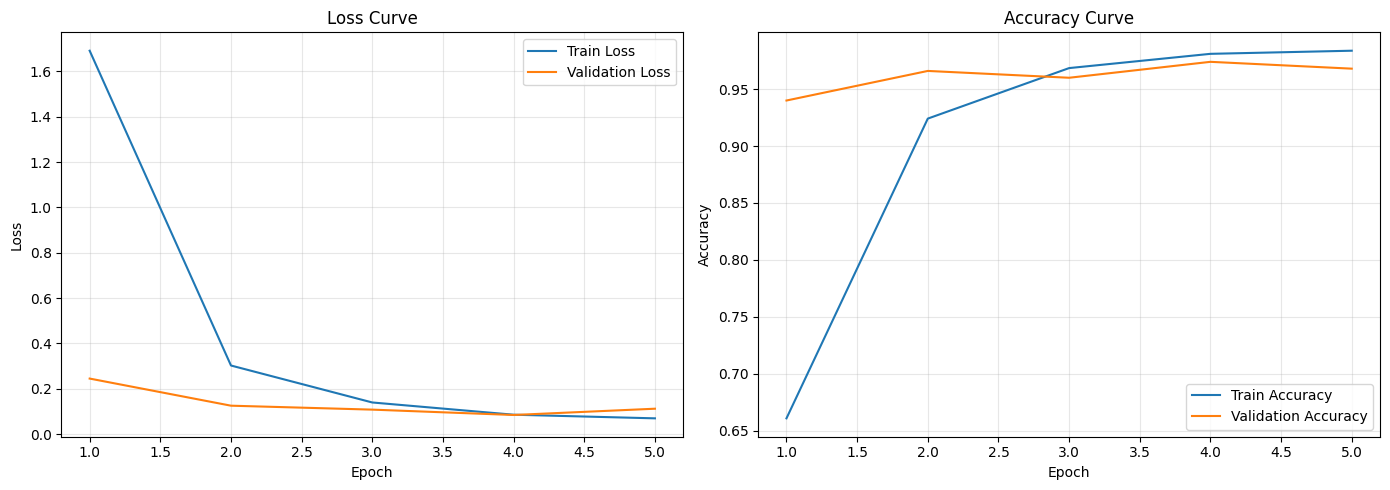

Test Loss: 0.0824 | Test Acc: 0.9760
                       precision    recall  f1-score   support

           air_hockey     1.0000    1.0000    1.0000         5
      ampute_football     1.0000    1.0000    1.0000         5
              archery     1.0000    1.0000    1.0000         5
        arm_wrestling     1.0000    1.0000    1.0000         5
         axe_throwing     1.0000    1.0000    1.0000         5
         balance_beam     1.0000    1.0000    1.0000         5
        barell_racing     1.0000    1.0000    1.0000         5
             baseball     1.0000    0.8000    0.8889         5
           basketball     0.8333    1.0000    0.9091         5
       baton_twirling     1.0000    1.0000    1.0000         5
            bike_polo     1.0000    1.0000    1.0000         5
            billiards     1.0000    1.0000    1.0000         5
                  bmx     1.0000    1.0000    1.0000         5
              bobsled     1.0000    1.0000    1.0000         5
              bow

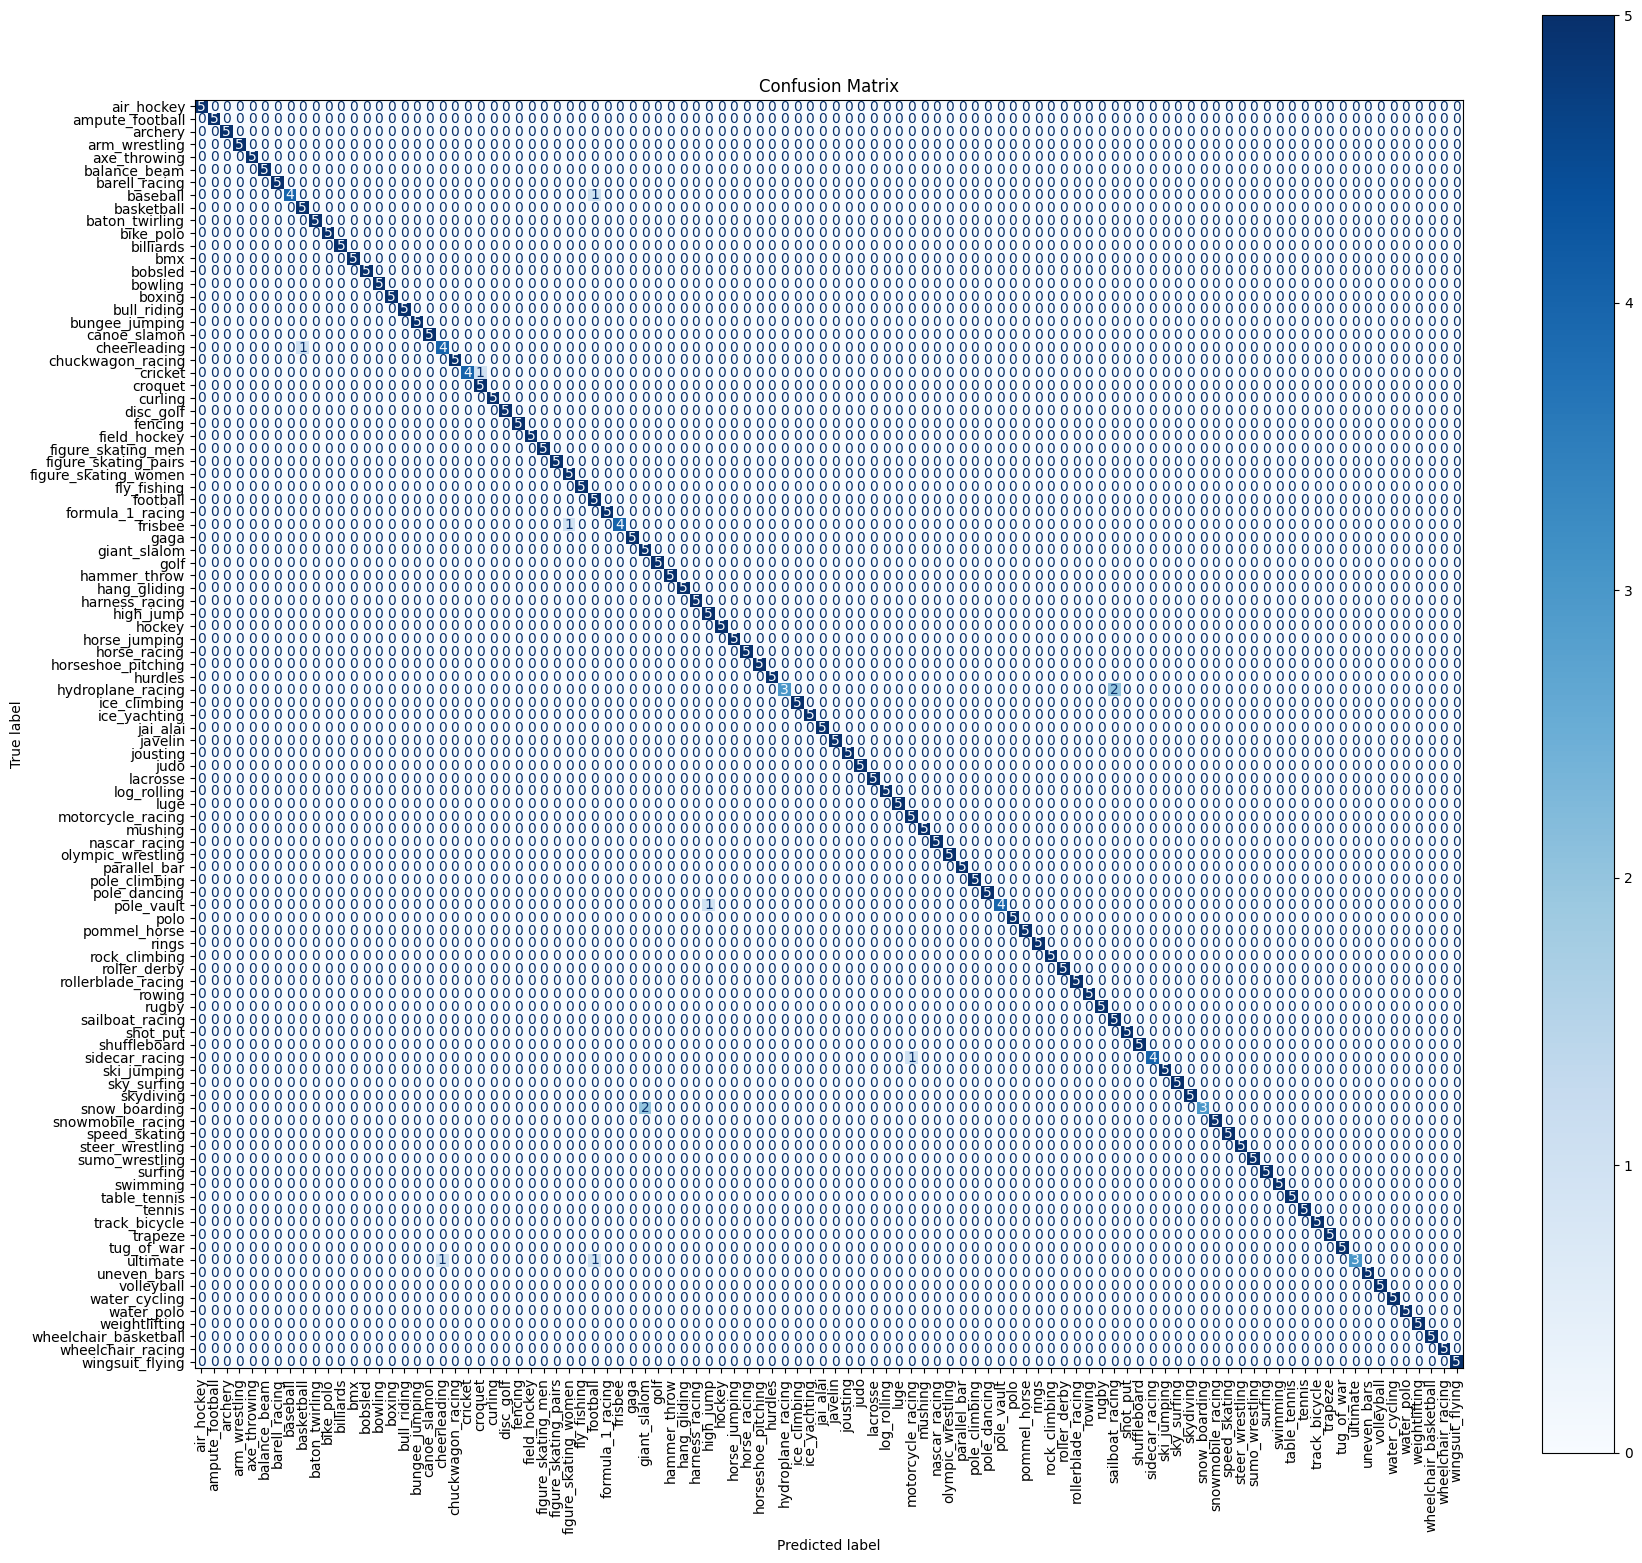

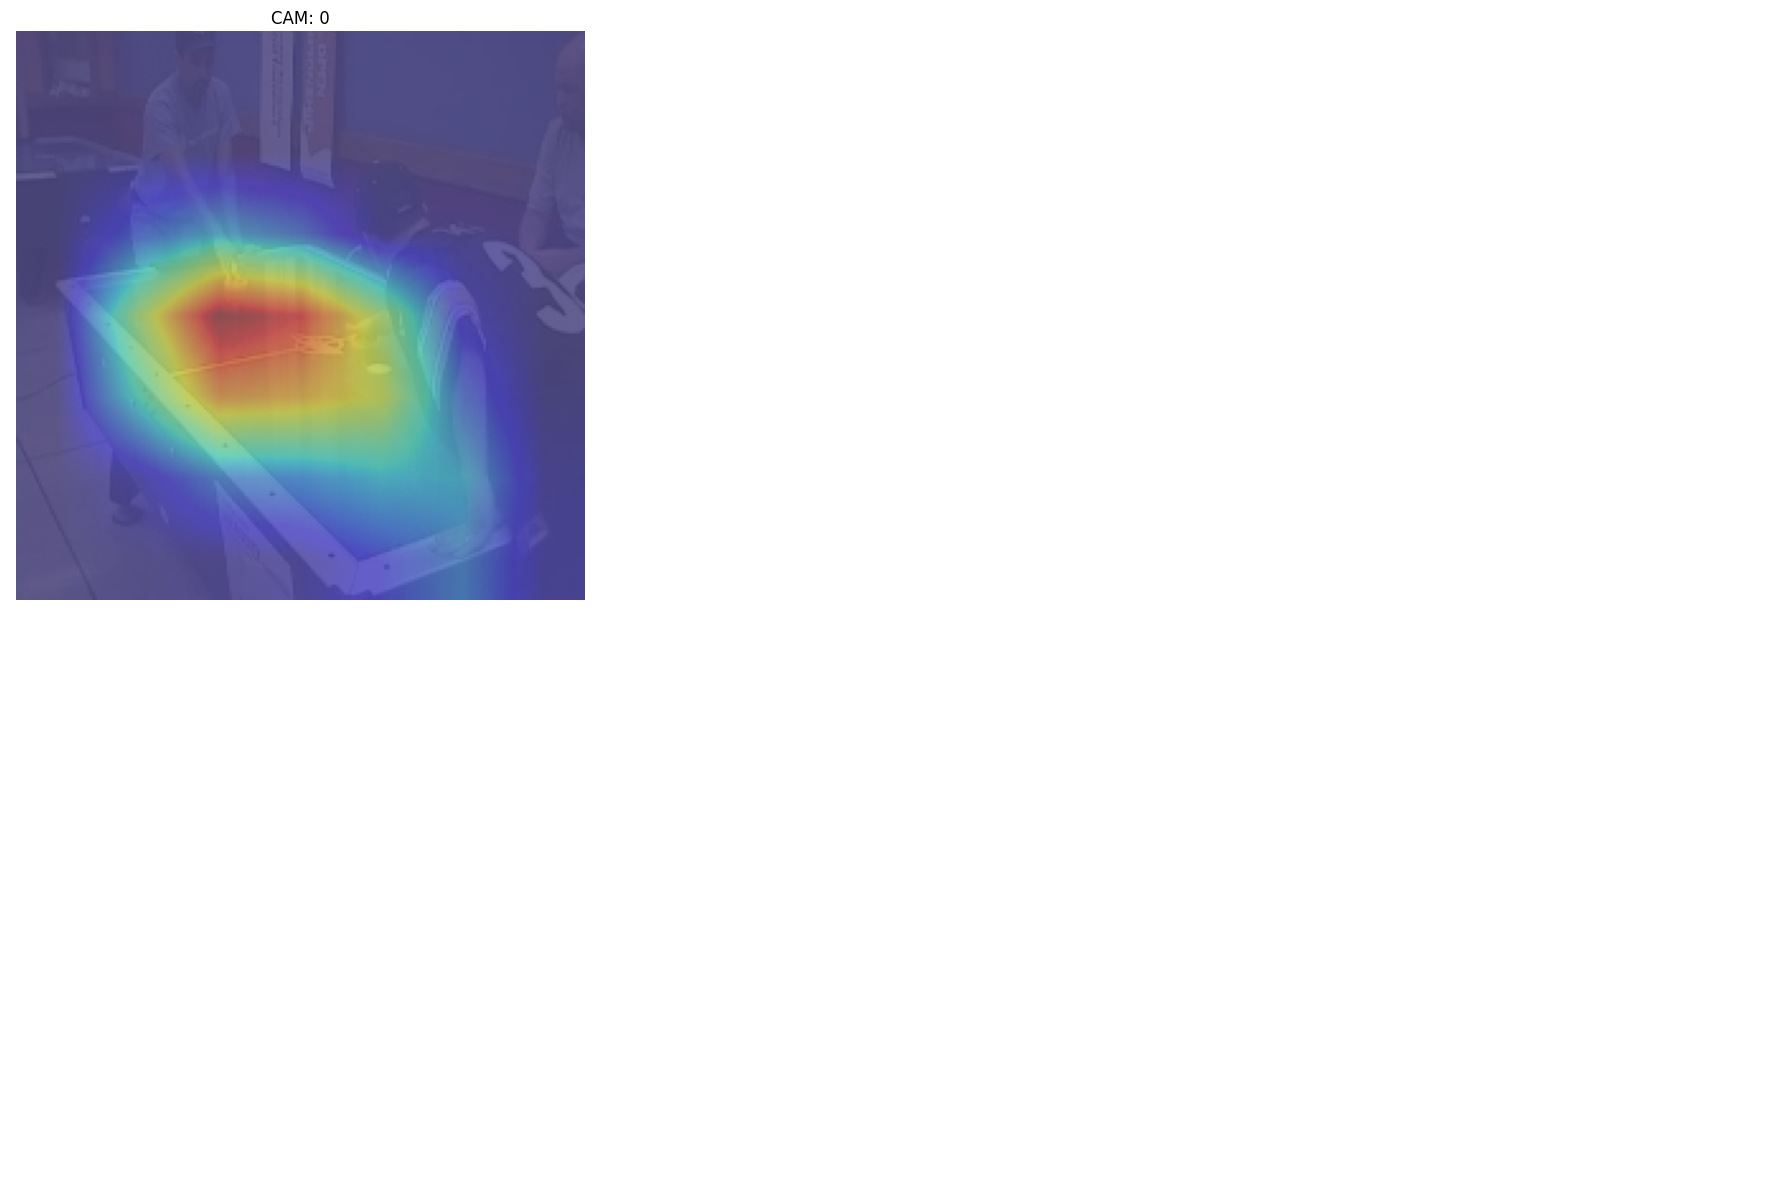

In [7]:
main()

In [ ]:
"""
Taken help from LLM tools like ChatGPT to code this notebook
"""